In [1]:
import pandas as pd 

df = pd.read_csv("C:/Users/LSG/Desktop/AICE_자료/AICE_Associate_실습코드/Clean_Dataset.csv")

df.drop([df.columns[0]], axis=1, inplace=True)

In [2]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [ ]:
# 랜덤하게 결측치 생성하기
import numpy as np
import random

# 같은 결과 출력을 위해 시드 고정
random.seed(2023)
np.random.seed(2023)

# 랜덤한 위치에 결층기 5000 개를 포함한 데이터 df_na 생성하기 
df_na = df.copy() # 데이터 복사
for i in range(0, 5000):
    df_na.iloc[random.randint(0, 300152), random.randint(0, 10)]=np.nan

In [4]:
# 결측치 처리 여부 확인을 위한 1번, 3번 인덱스 전체 결측치 처리하기 
df_na.iloc[1]=np.nan
df_na.iloc[3]=np.nan

In [5]:
df_na.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1.0,5953.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1.0,5956.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1.0,5955.0


In [6]:
df_na.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           299685 non-null  str    
 1   flight            299689 non-null  str    
 2   source_city       299681 non-null  str    
 3   departure_time    299723 non-null  str    
 4   stops             299666 non-null  str    
 5   arrival_time      299698 non-null  str    
 6   destination_city  299670 non-null  str    
 7   class             299715 non-null  str    
 8   duration          299703 non-null  float64
 9   days_left         299723 non-null  float64
 10  price             299714 non-null  float64
dtypes: float64(3), str(8)
memory usage: 25.2 MB


In [ ]:
df_na.isnull().sum(axis=0) # 0 = 기본값이므로 생략 가능

airline             468
flight              464
source_city         472
departure_time      430
stops               487
arrival_time        455
destination_city    483
class               438
duration            450
days_left           430
price               439
dtype: int64

In [11]:
# 원본 훼손 가능성 때문에 따로 저장
df_na_origin = df_na.copy()

In [ ]:
#결측치 삭제 - 손실 많음
df_na = df_na.dropna()
df_na.info()

<class 'pandas.DataFrame'>
Index: 295192 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           295192 non-null  str    
 1   flight            295192 non-null  str    
 2   source_city       295192 non-null  str    
 3   departure_time    295192 non-null  str    
 4   stops             295192 non-null  str    
 5   arrival_time      295192 non-null  str    
 6   destination_city  295192 non-null  str    
 7   class             295192 non-null  str    
 8   duration          295192 non-null  float64
 9   days_left         295192 non-null  float64
 10  price             295192 non-null  float64
dtypes: float64(3), str(8)
memory usage: 27.0 MB


<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           299685 non-null  str    
 1   flight            299689 non-null  str    
 2   source_city       299681 non-null  str    
 3   departure_time    299723 non-null  str    
 4   stops             299666 non-null  str    
 5   arrival_time      299698 non-null  str    
 6   destination_city  299670 non-null  str    
 7   class             299715 non-null  str    
 8   duration          299703 non-null  float64
 9   days_left         299723 non-null  float64
 10  price             299714 non-null  float64
dtypes: float64(3), str(8)
memory usage: 25.2 MB


In [17]:
# 결측치 삭제 전과 같은 상태로 되돌림
df_na = df_na_origin.copy()

# 모든 데이터가 결측치인 행만 삭제하기
df_na=df_na.dropna(how='all')
df_na.info()

<class 'pandas.DataFrame'>
Index: 300151 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           299685 non-null  str    
 1   flight            299689 non-null  str    
 2   source_city       299681 non-null  str    
 3   departure_time    299723 non-null  str    
 4   stops             299666 non-null  str    
 5   arrival_time      299698 non-null  str    
 6   destination_city  299670 non-null  str    
 7   class             299715 non-null  str    
 8   duration          299703 non-null  float64
 9   days_left         299723 non-null  float64
 10  price             299714 non-null  float64
dtypes: float64(3), str(8)
memory usage: 27.5 MB


In [ ]:
# 모든 데이터가 결측치였던 행만 삭제 되었는지 확인
df_na.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1.0,5953.0
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1.0,5956.0
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1.0,5955.0
5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1.0,5955.0
6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1.0,6060.0


In [ ]:
# 컬럼 제거하기 
df_na = df_na_origin.copy()

# df_na.drop(columns=['stops', 'flight']) 도 가능
df_na = df_na.drop(['stops','flight'], axis=1)
df_na.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           299685 non-null  str    
 1   source_city       299681 non-null  str    
 2   departure_time    299723 non-null  str    
 3   arrival_time      299698 non-null  str    
 4   destination_city  299670 non-null  str    
 5   class             299715 non-null  str    
 6   duration          299703 non-null  float64
 7   days_left         299723 non-null  float64
 8   price             299714 non-null  float64
dtypes: float64(3), str(6)
memory usage: 20.6 MB


In [ ]:
# 위 과정 후 다시 dropna로 결측치 존재 행 삭제
# 처음 dropna 했을 때보다 데이터 손실 적음
df_na = df_na.dropna()
df_na.info()

<class 'pandas.DataFrame'>
Index: 296124 entries, 0 to 300152
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           296124 non-null  str    
 1   source_city       296124 non-null  str    
 2   departure_time    296124 non-null  str    
 3   arrival_time      296124 non-null  str    
 4   destination_city  296124 non-null  str    
 5   class             296124 non-null  str    
 6   duration          296124 non-null  float64
 7   days_left         296124 non-null  float64
 8   price             296124 non-null  float64
dtypes: float64(3), str(6)
memory usage: 22.6 MB


In [29]:
# 결측치 평균값으로 대체
df_na = df_na_origin.copy()

df_na = df_na.fillna(df_na.mean(numeric_only=True))
df_na.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           299685 non-null  str    
 1   flight            299689 non-null  str    
 2   source_city       299681 non-null  str    
 3   departure_time    299723 non-null  str    
 4   stops             299666 non-null  str    
 5   arrival_time      299698 non-null  str    
 6   destination_city  299670 non-null  str    
 7   class             299715 non-null  str    
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  float64
 10  price             300153 non-null  float64
dtypes: float64(3), str(8)
memory usage: 25.2 MB


In [30]:
df_na.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.170000,1.000000,5953.000000
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.220991,26.006369,20888.967105
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.170000,1.000000,5956.000000
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.220991,26.006369,20888.967105
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.330000,1.000000,5955.000000


In [ ]:
# bfill(back fill/ front fill도 있음) - 뒤의 유효값 / 앞의 유효값 채움 3.xx 버전은 문법이 다름. 확인할것!
df_na = df_na.bfill()
df_na.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  str    
 1   flight            300153 non-null  str    
 2   source_city       300153 non-null  str    
 3   departure_time    300153 non-null  str    
 4   stops             300153 non-null  str    
 5   arrival_time      300153 non-null  str    
 6   destination_city  300153 non-null  str    
 7   class             300153 non-null  str    
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  float64
 10  price             300153 non-null  float64
dtypes: float64(3), str(8)
memory usage: 25.2 MB


In [ ]:
# z-score 모수가 실제로포함될 것을 예측하는 범위 
# (컬럼 - 컬럼 평균) / (컬럼 표준편차)
z_score = abs((df_na['price']-df_na['price'].mean())/df_na['price'].std())
# 양측 기준 약 95% 신뢰구간에 사용하는 값
df_na[z_score>1.96]

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
206691,Vistara,UK-809,Delhi,Evening,one,Morning,Mumbai,Business,12.42,1.0,74640.0
206692,Vistara,UK-813,Delhi,Evening,one,Morning,Mumbai,Business,14.67,1.0,74640.0
206693,Vistara,UK-809,Delhi,Evening,one,Night,Mumbai,Business,24.42,1.0,74640.0
206694,Vistara,UK-809,Delhi,Evening,one,Night,Mumbai,Business,26.00,1.0,74640.0
206695,Vistara,UK-813,Delhi,Evening,one,Night,Mumbai,Business,26.67,1.0,74640.0
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49.0,69265.0
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49.0,77105.0
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49.0,79099.0
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49.0,81585.0


In [52]:
# IQR 로 확인하기
# 제 3사분위수 - 제 1사분위수
# IQR 보다 1.5배 높으면 이상치로 판단할 가능성 높음
def findOutiers(x, column):

    # 제 1사분위수  q1 구하기
    q1 = x[column].quantile(0.25)

    # 제 3사분위수 q3 구하기
    q3 = x[column].quantile(0.75)

    # IQR의 1.5배수 
    iqr = 1.5 * (q3 - q1)


    y = x[(x[column] > (q3 + iqr)) | (x[column] < (q1 - iqr))]

    # iqr 기준 이상치 y 반환
    return len(y)


In [54]:
print('price 이상치 : ', findOutiers(df, 'price'))
print('duration 이상치 : ', findOutiers(df, 'duration'))
print('days_left 이상치 : ', findOutiers(df, 'days_left'))

price 이상치 :  123
duration 이상치 :  2110
days_left 이상치 :  0


Text(0, 0.5, 'price')

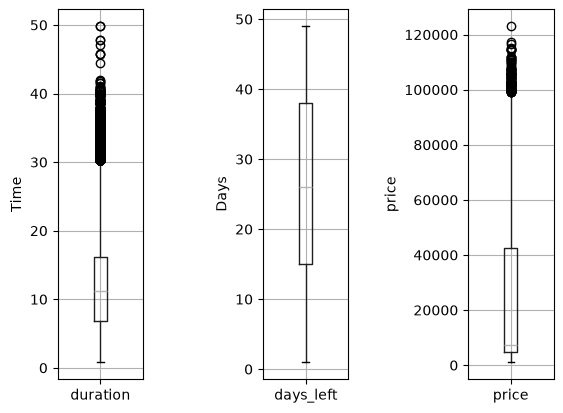

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

# 첫번째 subplot : 1행 5열로 나눈 영역에서 첫번째 영역
plt.subplot(151)
df[['duration']].boxplot()
plt.ylabel('Time')

# 두번째 subplot : 1 행 5열로 나눈 영역에서 세번째 영역
plt.subplot(153)
df[['days_left']].boxplot()
plt.ylabel('Days')

# 세번재 subplot : 1 행 5열로 나눈 영역에서 다섯번째 영역
plt.subplot(155)
df[['price']].boxplot()
plt.ylabel('price')

# 실행 결과에서 비행시간과 가격에 이상치가 있음을 확인할 수 있음

In [59]:
df_origin = df.copy()

In [61]:
# 이상치 데이터 삭제하기 
# 신뢰도 95% 기준 이상치 Index 추출
outier = df[(abs((df['price']-df['price'].mean())/df['price'].std()))>1.96].index

# 추출한 인덱스의 행 삭제해서 clean_df 데이터 만들기
clean_df = df.drop(outier)
clean_df.info()

<class 'pandas.DataFrame'>
Index: 287660 entries, 0 to 300146
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           287660 non-null  str    
 1   flight            287660 non-null  str    
 2   source_city       287660 non-null  str    
 3   departure_time    287660 non-null  str    
 4   stops             287660 non-null  str    
 5   arrival_time      287660 non-null  str    
 6   destination_city  287660 non-null  str    
 7   class             287660 non-null  str    
 8   duration          287660 non-null  float64
 9   days_left         287660 non-null  int64  
 10  price             287660 non-null  int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 26.3 MB


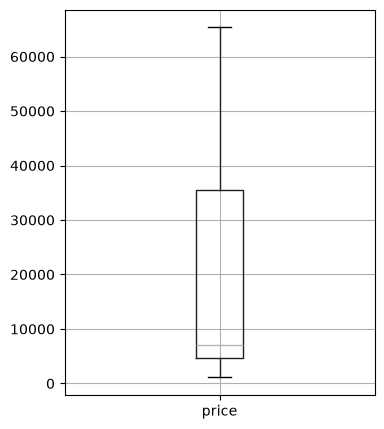

In [ ]:
# 이상치 제거 확인
plt.figure(figsize=(4, 5))

clean_df[['price']].boxplot()
plt.show()

Text(0, 0.5, '')

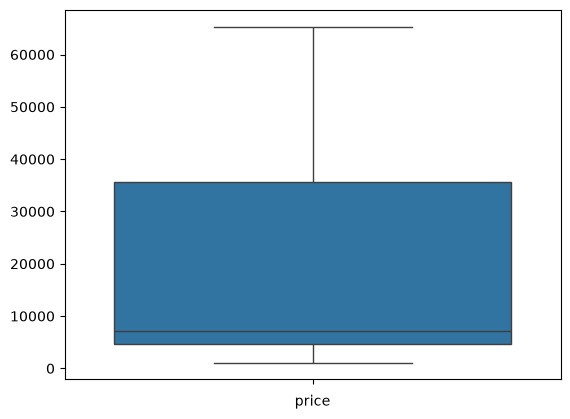

In [74]:
sns.boxplot(clean_df['price'])
plt.xlabel('price')
plt.ylabel('')

In [75]:
# IQR 기준 이상치를 대체하는 함수 만들기
def changeOutliers(x, column):

    q1 = x[column].quantile(0.25)
    q3 = x[column].quantile(0.75)

    iqr = 1.5 * (q3 - q1)

    Min = (q1 - iqr)
    Max = q3 + iqr

    x.loc[(x[column]> Max), column] = Max
    x.loc[(x[column]< Min), column] = Min

    return(x)

# price 이상치 대체
clean_df = changeOutliers(df, 'price')
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  str    
 1   flight            300153 non-null  str    
 2   source_city       300153 non-null  str    
 3   departure_time    300153 non-null  str    
 4   stops             300153 non-null  str    
 5   arrival_time      300153 non-null  str    
 6   destination_city  300153 non-null  str    
 7   class             300153 non-null  str    
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 25.2 MB


In [77]:
print('price 이상치 : ', findOutiers(clean_df, 'price'))

price 이상치 :  0


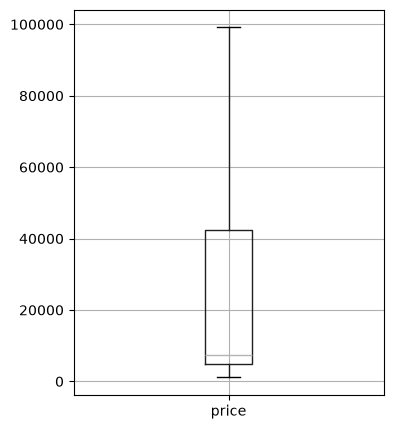

In [79]:
plt.figure(figsize=(4,5))

clean_df[['price']].boxplot()

plt.show()

In [80]:
# 비행 시간을 3개 구간으로 나누어 거리 컬럼 생성하기(cut - 구간으로 나눔)
df['distance'] = pd.cut(df['duration'], bins=[0, 5, 10, df['duration'].max()], labels=['short','medium','long'])
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,distance
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,short
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,short
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,short
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,short
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,short


In [85]:
df['distance'].value_counts()

distance
long      169879
medium     84761
short      45513
Name: count, dtype: int64

In [87]:
df['price_rate'] = pd.qcut(df['price'], 4, labels=['cheap', 'nomal', 'expensive', 'too expensive'])
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,distance,price_rate
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,short,nomal
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,short,nomal
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,short,nomal
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,short,nomal
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,short,nomal


In [88]:
df['price_rate'].value_counts()

price_rate
expensive        75584
nomal            75117
cheap            75073
too expensive    74379
Name: count, dtype: int64

In [ ]:
df = df_origin.copy()

# factorize로 airline 칼럼 레이블 인코딩하기
# [0] : airline의 변환된 숫자 코드 / 원래 범주 목록 중 변환된 숫자코드를 가져옴(index 개념)
df['label_encoding'] = pd.factorize(df['airline'])[0].reshape(-1,1)
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,label_encoding
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,0
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,0
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,1
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,2
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,2


In [96]:
print(df['airline'].value_counts())
print(df['label_encoding'].value_counts())

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64
label_encoding
2    127859
5     80892
4     43120
3     23173
1     16098
0      9011
Name: count, dtype: int64


In [ ]:
# sckit-learn LabelEncoder를 활용한 간단한 레이블 인코딩
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['airline_label_encoder'] = le.fit_transform(df['airline'])

# 알파벳 순으로 변환된 것 확인 가능
print(df['airline'].value_counts())
print(df['airline_label_encoder'].value_counts())

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64
airline_label_encoder
5    127859
1     80892
3     43120
2     23173
0     16098
4      9011
Name: count, dtype: int64


In [ ]:
# 레이블 인코딘 역변환(디코딩)하기
# -1 = 행 개수는 전체 데이터 개수에 맞게 알아서 계산해라
le.inverse_transform(df['airline_label_encoder']).reshape(-1, 1)

array([['SpiceJet'],
       ['SpiceJet'],
       ['AirAsia'],
       ...,
       ['Vistara'],
       ['Vistara'],
       ['Vistara']], shape=(300153, 1), dtype=object)

In [104]:
df = df_origin.copy()

# class 컬럼을 원핫 인코딩
df = pd.get_dummies(df, columns=['class'], dtype=int)
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,duration,days_left,price,class_Business,class_Economy
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,2.17,1,5953,0,1
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,2.33,1,5953,0,1
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,2.17,1,5956,0,1
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,2.25,1,5955,0,1
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,2.33,1,5955,0,1


In [ ]:
# 사이킷런으로 원핫 인코딩하기 
from sklearn.preprocessing import OneHotEncoder

df = df_origin.copy()

oh = OneHotEncoder()
# OneHotEncoder는 행과 열이 있는 2차원 형태로 받음
# 결과는 보통 메모리를 아끼기 위한 희소행렬 형태로 나오기 때문에 일반 numpy 배열로 변경
encoder = oh.fit_transform(df['class'].values.reshape(-1,1)).toarray()

In [ ]:
# 원핫 인코딩 결과를 데이터프레임으로 만들기(사실상 컬럼명 만드는 중)
df_OneHot = pd.DataFrame(encoder, columns=["class_" + str(oh.categories_[0][i]) for i in range(len(oh.categories_[0]))])

# 원핫 인코딩 결과 원본 데이터에 붙여넣기
df1 = pd.concat([df, df_OneHot], axis=1)
df1.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,class_Business,class_Economy
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,0.0,1.0
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,0.0,1.0
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,0.0,1.0
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,0.0,1.0
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,0.0,1.0
